In [18]:
# import json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats
# import warnings
# warnings.filterwarnings('ignore')

# # Load judged responses with response V/A
# with open('../results/final_run/judged_responses_new.json', 'r') as f:
#     data = json.load(f)

# print(f"Loaded {len(data)} responses")

# # Convert to DataFrame
# df = pd.json_normalize(data)

# # Flatten judgment columns
# df['task_focus'] = df['judgment.task_focus']
# df['emotional_leakage'] = df['judgment.emotional_leakage']
# df['empathy'] = df['judgment.empathy']
# df['answer_quality'] = df['judgment.answer_quality']
# df['answer_correctness'] = df['judgment.answer_correctness'].astype(int)

# # Calculate emotional alignment
# df['valence_alignment'] = np.abs(df['valence'] - df['valence_response'])
# df['arousal_alignment'] = np.abs(df['arousal'] - df['arousal_response'])

# # Calculate emotional distance (Euclidean in V/A space)
# df['emotional_distance'] = np.sqrt(
#     (df['valence'] - df['valence_response'])**2 + 
#     (df['arousal'] - df['arousal_response'])**2
# )

# print(f"\n✓ Data loaded with {len(df)} responses")
# print(f"Response Valence range: {df['valence_response'].min():.2f} - {df['valence_response'].max():.2f}")
# print(f"Response Arousal range: {df['arousal_response'].min():.2f} - {df['arousal_response'].max():.2f}")

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("LOADING DATA WITH RESPONSE V/A")
print("="*80)

# Load combined dataset (TruthfulQA + EmoBench + EQ-Bench)
print("\n1. Loading judged_responses_new.json (combined)...")
with open('../results/final_run/judged_responses_new.json', 'r') as f:
    combined_data = json.load(f)
print(f"   ✓ Loaded {len(combined_data)} responses")

# Load MMLU dataset
print("\n2. Loading judged_responses_mmlu_new.json...")
with open('../results/final_run/judged_responses_mmlu_new.json', 'r') as f:
    mmlu_data = json.load(f)
print(f"   ✓ Loaded {len(mmlu_data)} responses")

# Combine both datasets
print("\n3. Combining datasets...")
all_data = combined_data + mmlu_data
print(f"   ✓ Combined total: {len(all_data)} responses")

# Check for EQ-Bench (if you want to exclude it)
eqbench_count = sum(1 for item in all_data if item.get('source') == 'eqbench')
if eqbench_count > 0:
    print(f"\n   Note: {eqbench_count} EQ-Bench responses included")
    print(f"   (EQ-Bench may not have judgment scores)")
    
    # Option to filter out EQ-Bench
    all_data_with_judgments = [item for item in all_data if 'judgment' in item]
    print(f"   With judgments: {len(all_data_with_judgments)} responses")
else:
    all_data_with_judgments = all_data

# Convert to DataFrame
df = pd.json_normalize(all_data_with_judgments)

# Flatten judgment columns
df['task_focus'] = df['judgment.task_focus']
df['emotional_leakage'] = df['judgment.emotional_leakage']
df['empathy'] = df['judgment.empathy']
df['answer_quality'] = df['judgment.answer_quality']
df['answer_correctness'] = df['judgment.answer_correctness'].astype(int)

# Calculate emotional alignment
df['valence_alignment'] = np.abs(df['valence'] - df['valence_response'])
df['arousal_alignment'] = np.abs(df['arousal'] - df['arousal_response'])

# Calculate emotional distance (Euclidean in V/A space)
df['emotional_distance'] = np.sqrt(
    (df['valence'] - df['valence_response'])**2 + 
    (df['arousal'] - df['arousal_response'])**2
)

print("\n" + "="*80)
print("DATA SUMMARY")
print("="*80)
print(f"\nTotal responses: {len(df)}")
print(f"Response Valence range: {df['valence_response'].min():.2f} - {df['valence_response'].max():.2f}")
print(f"Response Arousal range: {df['arousal_response'].min():.2f} - {df['arousal_response'].max():.2f}")

print("\nBreakdown by source:")
for source in df['source'].unique():
    source_data = df[df['source'] == source]
    print(f"  {source}: {len(source_data)} responses ({source_data['answer_correctness'].mean():.1%} accuracy)")

print("\nBreakdown by emotion:")
for emotion in sorted(df['emotion'].unique()):
    emotion_data = df[df['emotion'] == emotion]
    print(f"  {emotion}: {len(emotion_data)} responses ({emotion_data['answer_correctness'].mean():.1%} accuracy)")

print("\n" + "="*80)
print("✓ DATA LOADED AND READY")
print("="*80)

LOADING DATA WITH RESPONSE V/A

1. Loading judged_responses_new.json (combined)...
   ✓ Loaded 1000 responses

2. Loading judged_responses_mmlu_new.json...
   ✓ Loaded 1300 responses

3. Combining datasets...
   ✓ Combined total: 2300 responses

DATA SUMMARY

Total responses: 2300
Response Valence range: 2.49 - 7.65
Response Arousal range: 1.55 - 7.34

Breakdown by source:
  truthfulqa: 500 responses (46.8% accuracy)
  emobench: 500 responses (42.0% accuracy)
  mmlu: 1300 responses (35.4% accuracy)

Breakdown by emotion:
  control: 230 responses (47.0% accuracy)
  depressed: 230 responses (20.9% accuracy)
  enraged: 230 responses (37.0% accuracy)
  euphoric: 230 responses (45.7% accuracy)
  excited: 230 responses (43.5% accuracy)
  focused: 230 responses (45.2% accuracy)
  grateful: 230 responses (42.2% accuracy)
  hopeless: 230 responses (39.1% accuracy)
  peaceful: 230 responses (45.2% accuracy)
  terrified: 230 responses (27.4% accuracy)

✓ DATA LOADED AND READY


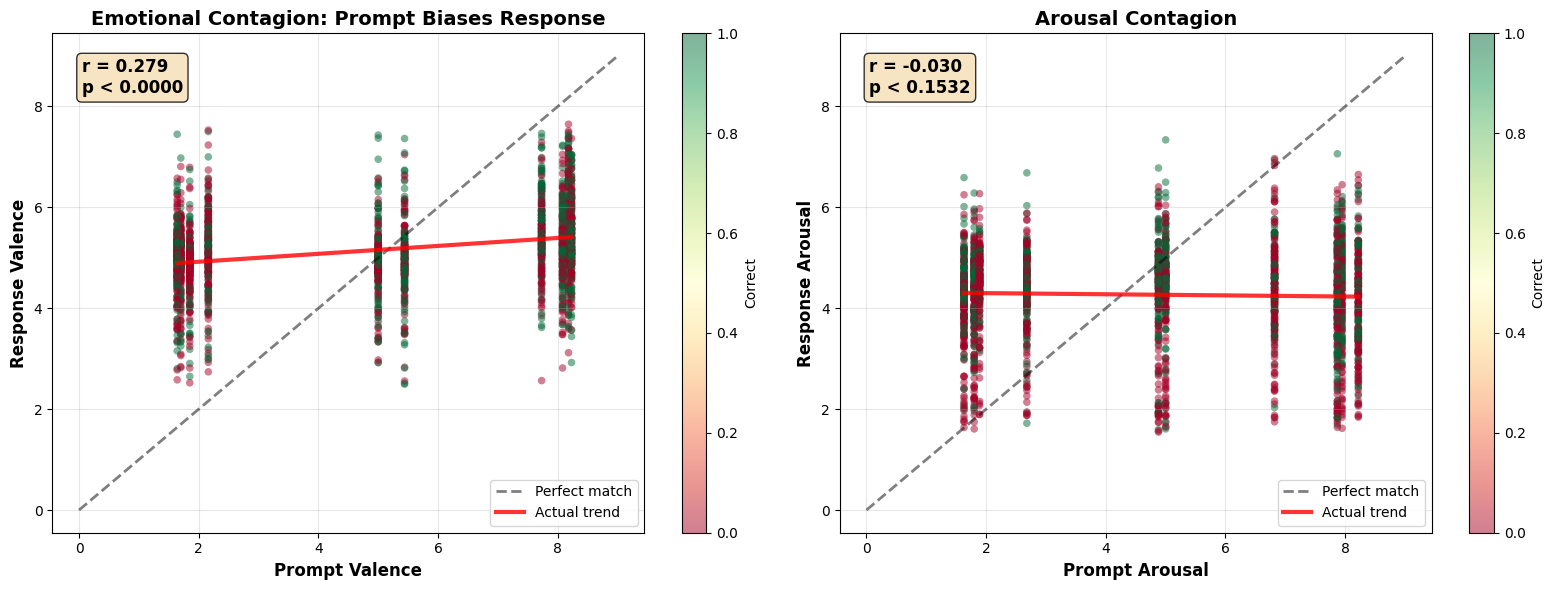


Emotional Contagion Statistics:
Prompt Valence → Response Valence: r=-0.030, p=0.153162
Prompt Arousal → Response Arousal: r=-0.030, p=0.153162


In [ ]:
# Test: Do emotional prompts bias response emotion?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Prompt Valence → Response Valence
ax = axes[0]
scatter = ax.scatter(df['valence'], df['valence_response'], 
                     c=df['answer_correctness'], cmap='RdYlGn',
                     s=30, alpha=0.5, edgecolors='none')

# Perfect match line
ax.plot([0, 9], [0, 9], 'k--', linewidth=2, alpha=0.5, label='Perfect match')

# Regression line
z = np.polyfit(df['valence'], df['valence_response'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['valence'].min(), df['valence'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=3, alpha=0.8, label='Actual trend')

# Stats
corr, p_val = stats.pearsonr(df['valence'], df['valence_response'])
ax.text(0.05, 0.95, f'r = {corr:.3f}\np < {p_val:.4f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontweight='bold')

ax.set_xlabel('Prompt Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Valence', fontsize=12, fontweight='bold')
ax.set_title('Emotional Contagion: Prompt Biases Response', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Correct', fontsize=10)

# RIGHT: Prompt Arousal → Response Arousal
ax = axes[1]
scatter = ax.scatter(df['arousal'], df['arousal_response'], 
                     c=df['answer_correctness'], cmap='RdYlGn',
                     s=30, alpha=0.5, edgecolors='none')

ax.plot([0, 9], [0, 9], 'k--', linewidth=2, alpha=0.5, label='Perfect match')

z = np.polyfit(df['arousal'], df['arousal_response'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['arousal'].min(), df['arousal'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=3, alpha=0.8, label='Actual trend')

corr, p_val = stats.pearsonr(df['arousal'], df['arousal_response'])
ax.text(0.05, 0.95, f'r = {corr:.3f}\np < {p_val:.4f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontweight='bold')

ax.set_xlabel('Prompt Arousal', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Arousal', fontsize=12, fontweight='bold')
ax.set_title('Arousal Contagion', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Correct', fontsize=10)

plt.tight_layout()
# plt.savefig('../visualizations/emotional_contagion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEmotional Contagion Statistics:")
print(f"Prompt Valence → Response Valence: r={corr:.3f}, p={p_val:.6f}")
corr_a, p_a = stats.pearsonr(df['arousal'], df['arousal_response'])
print(f"Prompt Arousal → Response Arousal: r={corr_a:.3f}, p={p_a:.6f}")

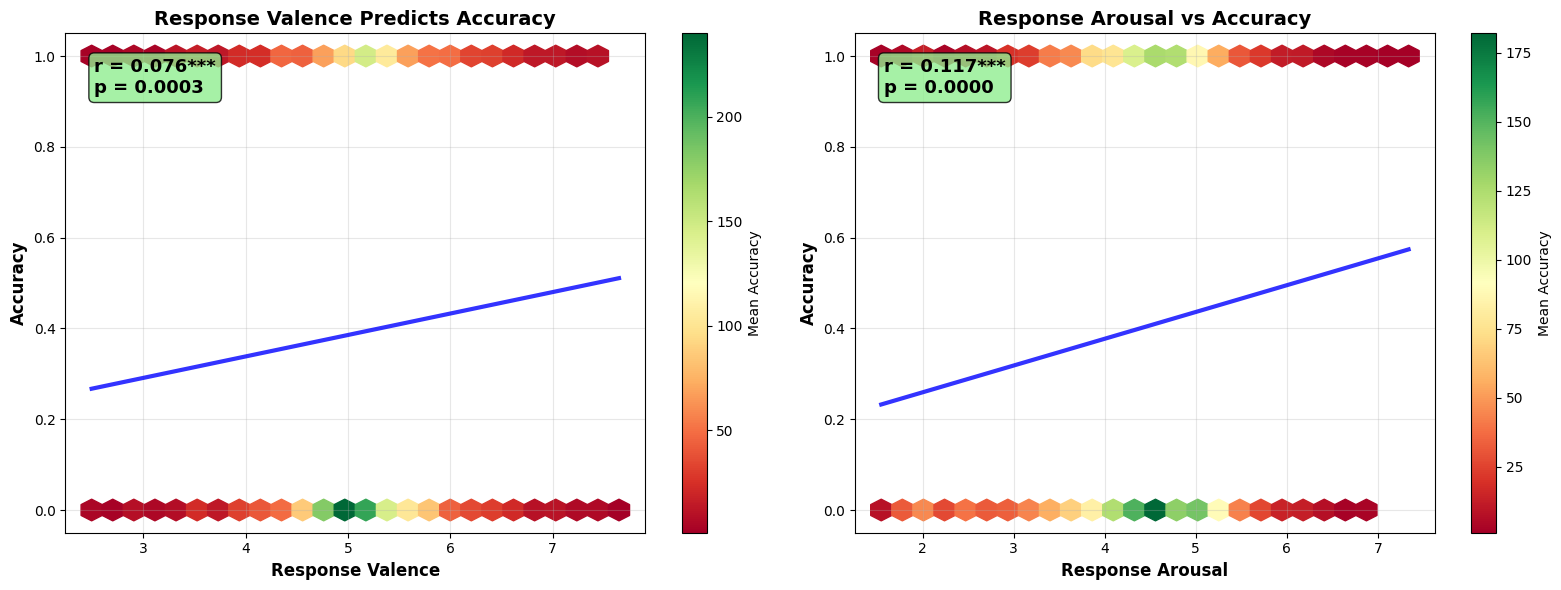


Response Emotion → Accuracy:
Response Valence → Accuracy: r=0.076, p=0.000267
Response Arousal → Accuracy: r=0.117, p=0.000000


In [ ]:
# Show that RESPONSE emotion predicts accuracy

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Response Valence → Accuracy (Hexbin for density)
ax = axes[0]
hexbin = ax.hexbin(df['valence_response'], df['answer_correctness'], 
                   gridsize=25, cmap='RdYlGn', mincnt=1, 
                   reduce_C_function=np.mean)

# Add regression line
z = np.polyfit(df['valence_response'], df['answer_correctness'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['valence_response'].min(), df['valence_response'].max(), 100)
ax.plot(x_line, p(x_line), 'b-', linewidth=3, alpha=0.8)

# Stats
corr, p_val = stats.pearsonr(df['valence_response'], df['answer_correctness'])
significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
color = 'lightgreen' if p_val < 0.05 else 'wheat'

ax.text(0.05, 0.95, f'r = {corr:.3f}{significance}\np = {p_val:.4f}', 
        transform=ax.transAxes, fontsize=13, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=color, alpha=0.8),
        fontweight='bold')

ax.set_xlabel('Response Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Response Valence Predicts Accuracy', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Mean Accuracy', fontsize=10)

# RIGHT: Response Arousal → Accuracy
ax = axes[1]
hexbin = ax.hexbin(df['arousal_response'], df['answer_correctness'], 
                   gridsize=25, cmap='RdYlGn', mincnt=1,
                   reduce_C_function=np.mean)

z = np.polyfit(df['arousal_response'], df['answer_correctness'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['arousal_response'].min(), df['arousal_response'].max(), 100)
ax.plot(x_line, p(x_line), 'b-', linewidth=3, alpha=0.8)

corr, p_val = stats.pearsonr(df['arousal_response'], df['answer_correctness'])
significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
color = 'lightgreen' if p_val < 0.05 else 'wheat'

ax.text(0.05, 0.95, f'r = {corr:.3f}{significance}\np = {p_val:.4f}', 
        transform=ax.transAxes, fontsize=13, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=color, alpha=0.8),
        fontweight='bold')

ax.set_xlabel('Response Arousal', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Response Arousal vs Accuracy', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Mean Accuracy', fontsize=10)

plt.tight_layout()
# plt.savefig('../visualizations/response_emotion_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nResponse Emotion → Accuracy:")
corr_v, p_v = stats.pearsonr(df['valence_response'], df['answer_correctness'])
corr_a, p_a = stats.pearsonr(df['arousal_response'], df['answer_correctness'])
print(f"Response Valence → Accuracy: r={corr_v:.3f}, p={p_v:.6f}")
print(f"Response Arousal → Accuracy: r={corr_a:.3f}, p={p_a:.6f}")

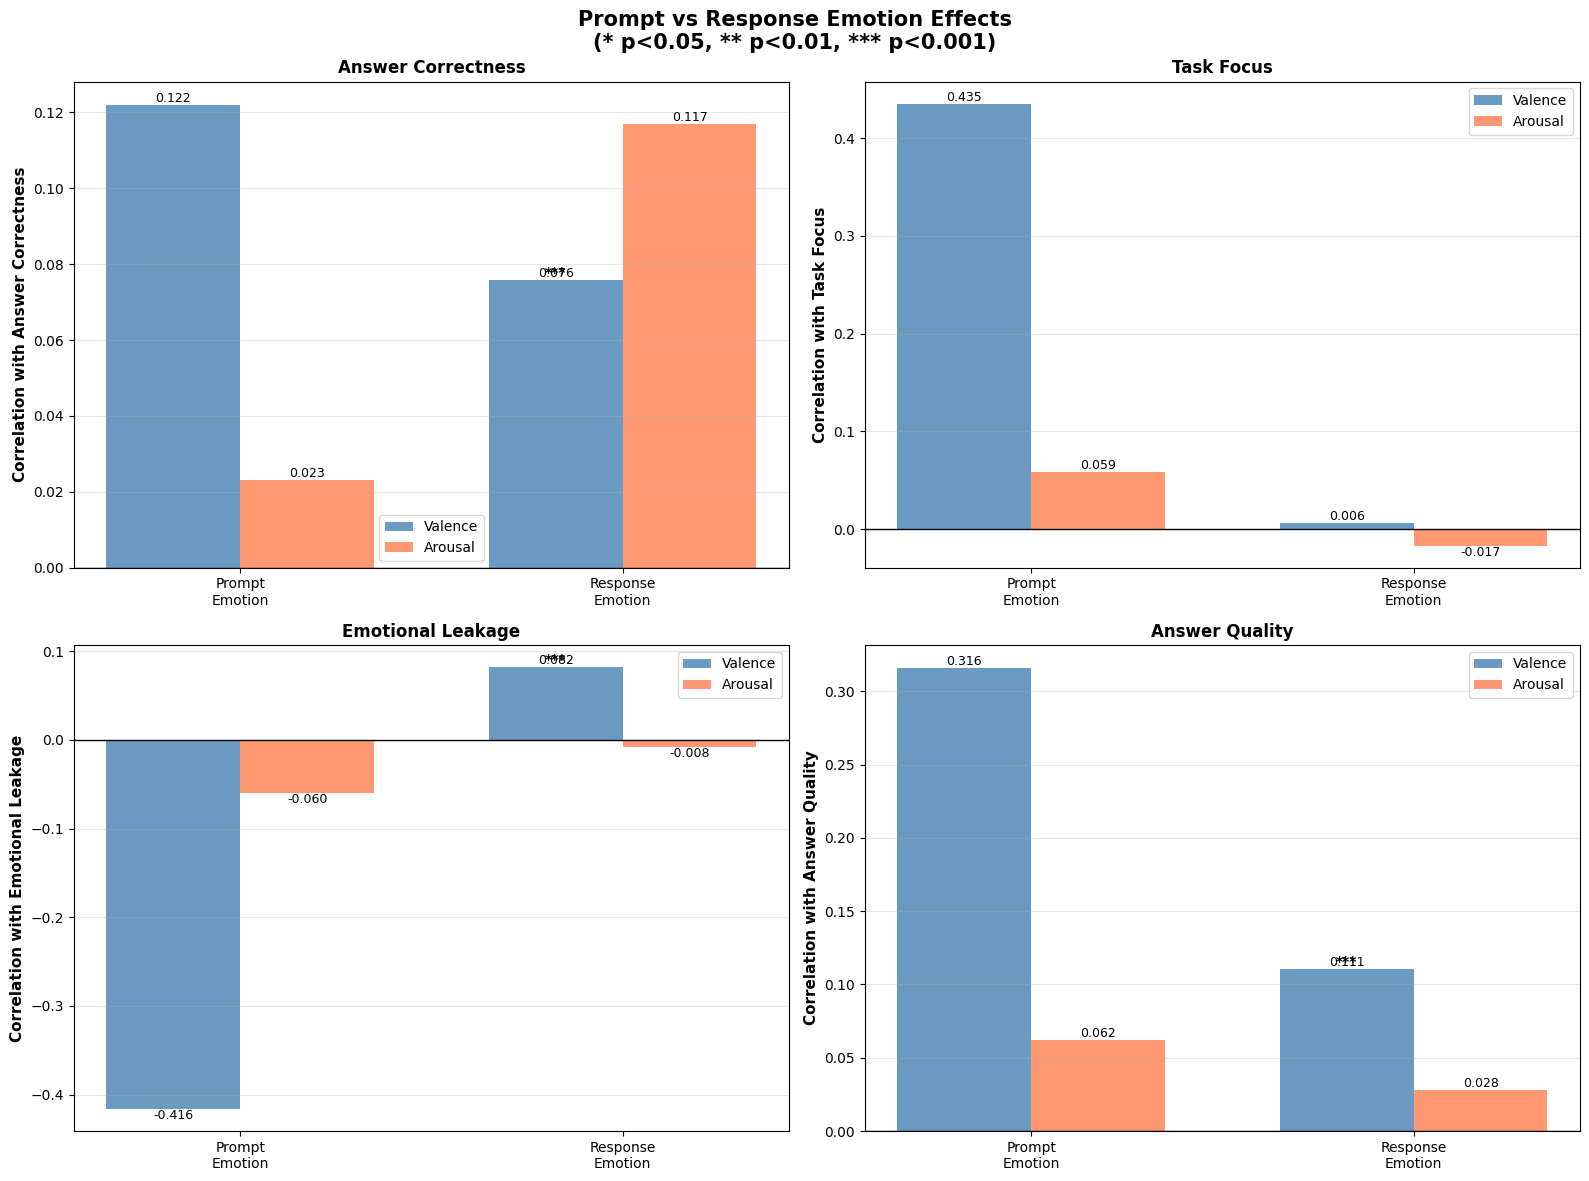


Comparison Table:
            Metric  Prompt Valence  Response Valence  Prompt Arousal  Response Arousal
Answer Correctness        0.122031          0.075943        0.023079          0.116832
        Task Focus        0.435230          0.006012        0.058504         -0.016940
 Emotional Leakage       -0.416259          0.082198       -0.060292         -0.007505
    Answer Quality        0.315857          0.110723        0.062396          0.028223


In [ ]:
# Compare: Does prompt or response emotion matter more?

# Calculate all correlations
metrics = ['answer_correctness', 'task_focus', 'emotional_leakage', 'answer_quality']
results = []

for metric in metrics:
    # Prompt correlations
    corr_prompt_val, p_prompt_val = stats.pearsonr(df['valence'], df[metric])
    corr_prompt_aro, p_prompt_aro = stats.pearsonr(df['arousal'], df[metric])
    
    # Response correlations
    corr_resp_val, p_resp_val = stats.pearsonr(df['valence_response'], df[metric])
    corr_resp_aro, p_resp_aro = stats.pearsonr(df['arousal_response'], df[metric])
    
    results.append({
        'Metric': metric.replace('_', ' ').title(),
        'Prompt Valence': corr_prompt_val,
        'Prompt Arousal': corr_prompt_aro,
        'Response Valence': corr_resp_val,
        'Response Arousal': corr_resp_aro,
        'Resp Val p': p_resp_val,
        'Resp Aro p': p_resp_aro
    })

results_df = pd.DataFrame(results)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    row = results_df[results_df['Metric'] == metric.replace('_', ' ').title()].iloc[0]
    
    x = np.arange(2)
    width = 0.35
    
    # Valence comparison
    bars1 = ax.bar(x - width/2, [row['Prompt Valence'], row['Response Valence']], 
                   width, label='Valence', color='steelblue', alpha=0.8)
    
    # Arousal comparison  
    bars2 = ax.bar(x + width/2, [row['Prompt Arousal'], row['Response Arousal']], 
                   width, label='Arousal', color='coral', alpha=0.8)
    
    # Add significance stars
    if row['Resp Val p'] < 0.001:
        ax.text(1 - width/2, row['Response Valence'], '***', ha='center', va='bottom', fontweight='bold')
    elif row['Resp Val p'] < 0.01:
        ax.text(1 - width/2, row['Response Valence'], '**', ha='center', va='bottom', fontweight='bold')
    elif row['Resp Val p'] < 0.05:
        ax.text(1 - width/2, row['Response Valence'], '*', ha='center', va='bottom', fontweight='bold')
    
    ax.set_ylabel('Correlation with ' + row['Metric'], fontsize=11, fontweight='bold')
    ax.set_title(row['Metric'], fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Prompt\nEmotion', 'Response\nEmotion'])
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

plt.suptitle('Prompt vs Response Emotion Effects\n(* p<0.05, ** p<0.01, *** p<0.001)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/prompt_vs_response_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nComparison Table:")
print(results_df[['Metric', 'Prompt Valence', 'Response Valence', 'Prompt Arousal', 'Response Arousal']].to_string(index=False))

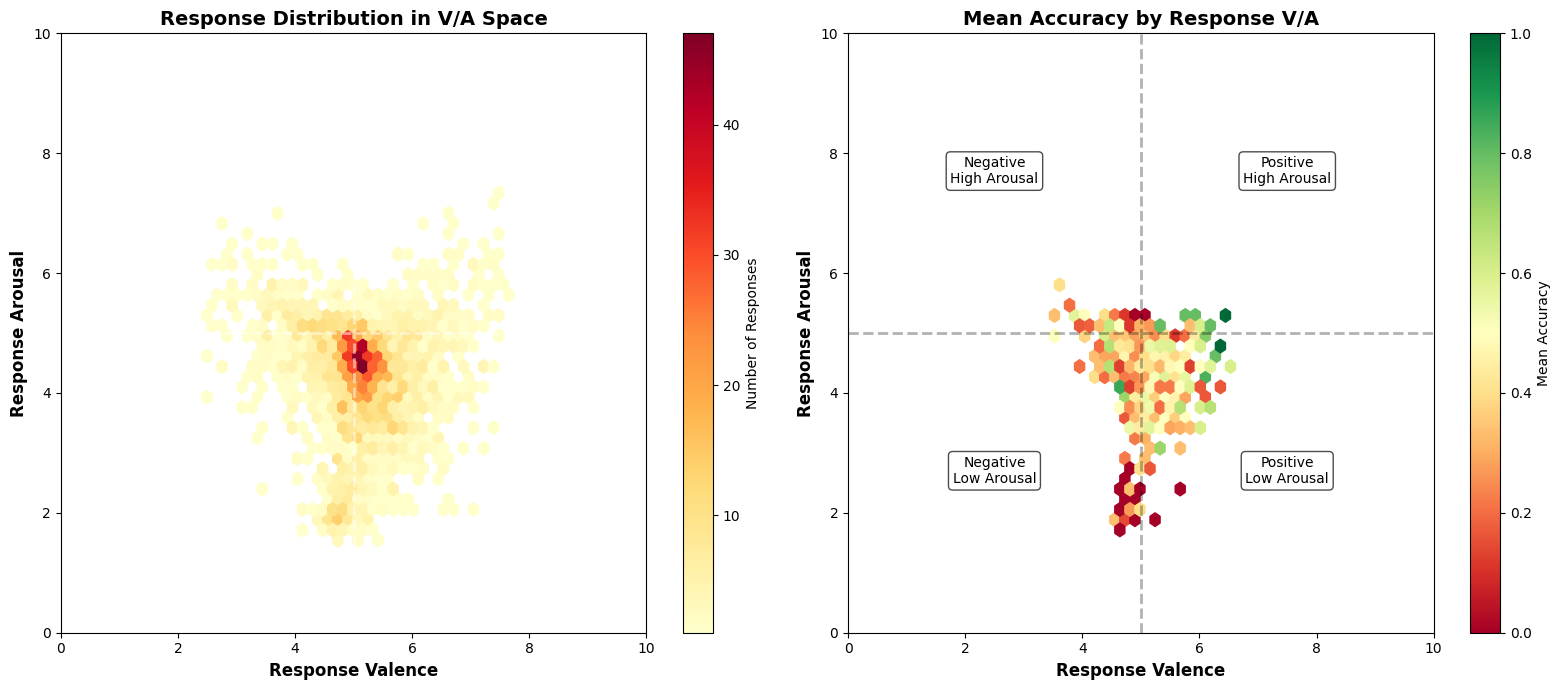


Accuracy by Response Quadrant:
negative_low_arousal: n=677, Accuracy=33.4%
positive_low_arousal: n=1158, Accuracy=41.6%
positive_high_arousal: n=209, Accuracy=49.8%
negative_high_arousal: n=256, Accuracy=35.9%


In [ ]:
# Show where in V/A space responses cluster and their accuracy

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Density heatmap of responses
ax = axes[0]
heatmap = ax.hexbin(df['valence_response'], df['arousal_response'], 
                    gridsize=30, cmap='YlOrRd', mincnt=1)

ax.set_xlabel('Response Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Arousal', fontsize=12, fontweight='bold')
ax.set_title('Response Distribution in V/A Space', fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Add quadrant lines
ax.axhline(y=5, color='white', linestyle='--', alpha=0.5, linewidth=2)
ax.axvline(x=5, color='white', linestyle='--', alpha=0.5, linewidth=2)

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Number of Responses', fontsize=10)

# RIGHT: Mean accuracy heatmap
ax = axes[1]
heatmap = ax.hexbin(df['valence_response'], df['arousal_response'], 
                    C=df['answer_correctness'], gridsize=30, 
                    cmap='RdYlGn', mincnt=5, reduce_C_function=np.mean,
                    vmin=0, vmax=1)

ax.set_xlabel('Response Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Arousal', fontsize=12, fontweight='bold')
ax.set_title('Mean Accuracy by Response V/A', fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.axhline(y=5, color='black', linestyle='--', alpha=0.3, linewidth=2)
ax.axvline(x=5, color='black', linestyle='--', alpha=0.3, linewidth=2)

# Add quadrant labels
ax.text(2.5, 7.5, 'Negative\nHigh Arousal', ha='center', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(7.5, 7.5, 'Positive\nHigh Arousal', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(2.5, 2.5, 'Negative\nLow Arousal', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(7.5, 2.5, 'Positive\nLow Arousal', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Mean Accuracy', fontsize=10)

plt.tight_layout()
# plt.savefig('../visualizations/response_va_space_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate accuracy by quadrant (based on response V/A)
df['response_quadrant'] = 'neutral'
df.loc[(df['valence_response'] > 5) & (df['arousal_response'] > 5), 'response_quadrant'] = 'positive_high_arousal'
df.loc[(df['valence_response'] > 5) & (df['arousal_response'] <= 5), 'response_quadrant'] = 'positive_low_arousal'
df.loc[(df['valence_response'] <= 5) & (df['arousal_response'] > 5), 'response_quadrant'] = 'negative_high_arousal'
df.loc[(df['valence_response'] <= 5) & (df['arousal_response'] <= 5), 'response_quadrant'] = 'negative_low_arousal'

print("\nAccuracy by Response Quadrant:")
for quad in df['response_quadrant'].unique():
    quad_data = df[df['response_quadrant'] == quad]
    print(f"{quad}: n={len(quad_data)}, Accuracy={quad_data['answer_correctness'].mean():.1%}")

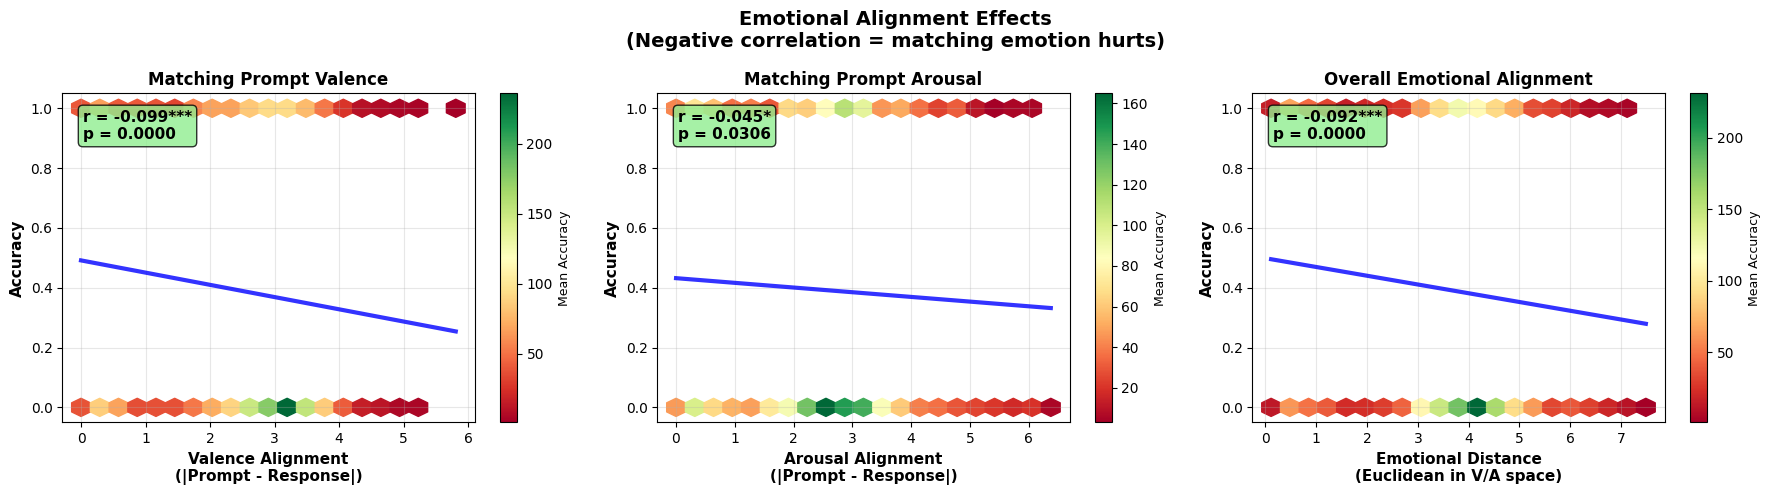


Emotional Alignment → Accuracy:
Valence Alignment: r=-0.099, p=0.000002
Arousal Alignment: r=-0.045, p=0.030586
Emotional Distance: r=-0.092, p=0.000010

Interpretation: Negative r = responses matching prompt emotion perform WORSE


In [ ]:
# Does response matching prompt emotion hurt accuracy?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LEFT: Valence alignment → Accuracy
ax = axes[0]
hexbin = ax.hexbin(df['valence_alignment'], df['answer_correctness'], 
                   gridsize=20, cmap='RdYlGn', mincnt=1,
                   reduce_C_function=np.mean)

z = np.polyfit(df['valence_alignment'], df['answer_correctness'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['valence_alignment'].min(), df['valence_alignment'].max(), 100)
ax.plot(x_line, p(x_line), 'b-', linewidth=3, alpha=0.8)

corr, p_val = stats.pearsonr(df['valence_alignment'], df['answer_correctness'])
significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

ax.text(0.05, 0.95, f'r = {corr:.3f}{significance}\np = {p_val:.4f}', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen' if p_val < 0.05 else 'wheat', alpha=0.8),
        fontweight='bold')

ax.set_xlabel('Valence Alignment\n(|Prompt - Response|)', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Matching Prompt Valence', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Mean Accuracy', fontsize=9)

# MIDDLE: Arousal alignment → Accuracy
ax = axes[1]
hexbin = ax.hexbin(df['arousal_alignment'], df['answer_correctness'], 
                   gridsize=20, cmap='RdYlGn', mincnt=1,
                   reduce_C_function=np.mean)

z = np.polyfit(df['arousal_alignment'], df['answer_correctness'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['arousal_alignment'].min(), df['arousal_alignment'].max(), 100)
ax.plot(x_line, p(x_line), 'b-', linewidth=3, alpha=0.8)

corr, p_val = stats.pearsonr(df['arousal_alignment'], df['answer_correctness'])
significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

ax.text(0.05, 0.95, f'r = {corr:.3f}{significance}\np = {p_val:.4f}', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen' if p_val < 0.05 else 'wheat', alpha=0.8),
        fontweight='bold')

ax.set_xlabel('Arousal Alignment\n(|Prompt - Response|)', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Matching Prompt Arousal', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Mean Accuracy', fontsize=9)

# RIGHT: Emotional distance → Accuracy
ax = axes[2]
hexbin = ax.hexbin(df['emotional_distance'], df['answer_correctness'], 
                   gridsize=20, cmap='RdYlGn', mincnt=1,
                   reduce_C_function=np.mean)

z = np.polyfit(df['emotional_distance'], df['answer_correctness'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['emotional_distance'].min(), df['emotional_distance'].max(), 100)
ax.plot(x_line, p(x_line), 'b-', linewidth=3, alpha=0.8)

corr, p_val = stats.pearsonr(df['emotional_distance'], df['answer_correctness'])
significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

ax.text(0.05, 0.95, f'r = {corr:.3f}{significance}\np = {p_val:.4f}', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen' if p_val < 0.05 else 'wheat', alpha=0.8),
        fontweight='bold')

ax.set_xlabel('Emotional Distance\n(Euclidean in V/A space)', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Overall Emotional Alignment', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Mean Accuracy', fontsize=9)

plt.suptitle('Emotional Alignment Effects\n(Negative correlation = matching emotion hurts)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/emotional_alignment.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEmotional Alignment → Accuracy:")
corr_v, p_v = stats.pearsonr(df['valence_alignment'], df['answer_correctness'])
corr_a, p_a = stats.pearsonr(df['arousal_alignment'], df['answer_correctness'])
corr_d, p_d = stats.pearsonr(df['emotional_distance'], df['answer_correctness'])
print(f"Valence Alignment: r={corr_v:.3f}, p={p_v:.6f}")
print(f"Arousal Alignment: r={corr_a:.3f}, p={p_a:.6f}")
print(f"Emotional Distance: r={corr_d:.3f}, p={p_d:.6f}")
print("\nInterpretation: Negative r = responses matching prompt emotion perform WORSE")

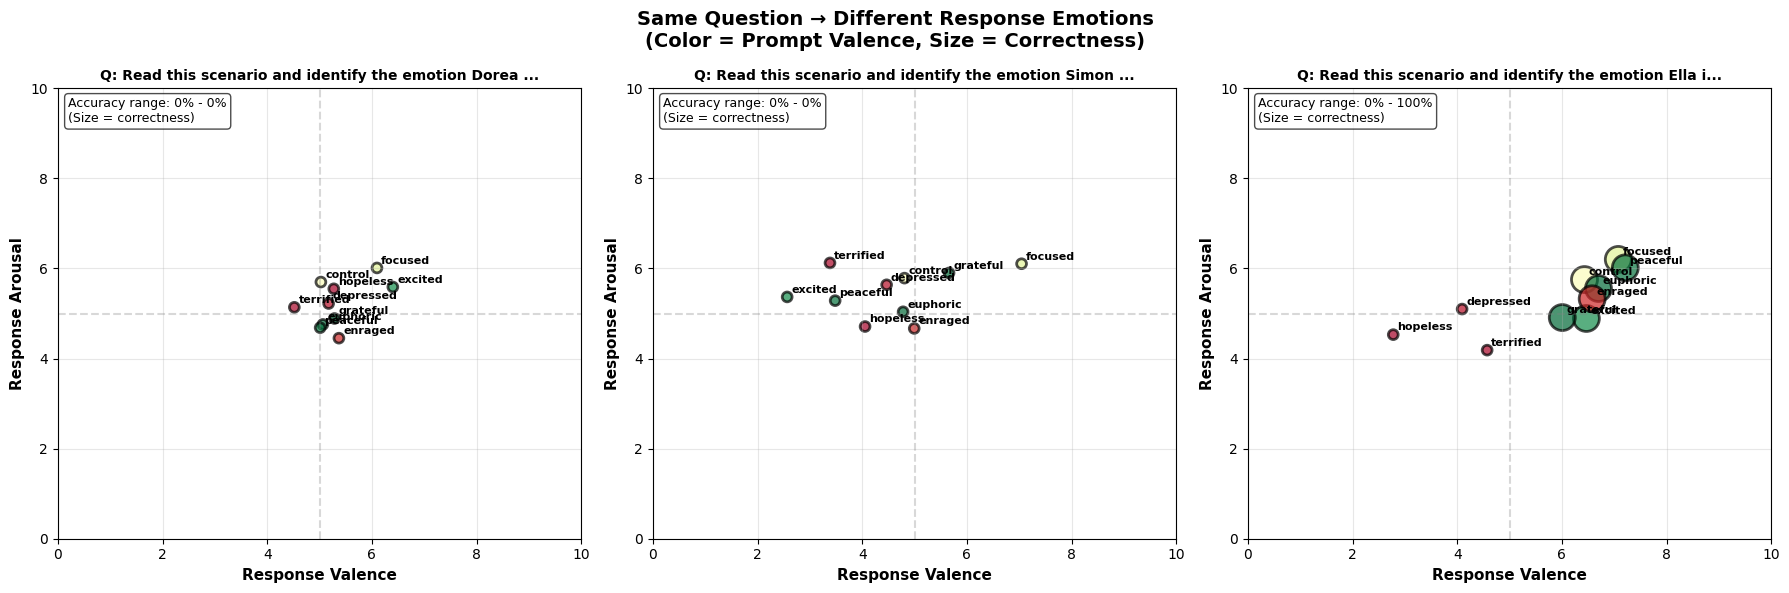


Example questions:

emobench_0:
  Question: Read this scenario and identify the emotion Dorea is feeling:

Dorea was trying ...
  Appears in 10 emotional conditions
  Response valence range: 4.52 - 6.40
  Accuracy range: 0% - 0%

emobench_1:
  Question: Read this scenario and identify the emotion Simon is feeling:

Simon, an amateur...
  Appears in 10 emotional conditions
  Response valence range: 2.57 - 7.05
  Accuracy range: 0% - 0%

emobench_10:
  Question: Read this scenario and identify the emotion Ella is feeling:

Ella was up the en...
  Appears in 10 emotional conditions
  Response valence range: 2.78 - 7.21
  Accuracy range: 0% - 100%


In [ ]:
# Show how response V/A varies for the same question across emotions

# Pick a question that appears in multiple emotions
question_counts = df.groupby('question_id').size()
common_questions = question_counts[question_counts >= 5].index[:3]  # Top 3 most common

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, qid in enumerate(common_questions):
    ax = axes[idx]
    
    q_data = df[df['question_id'] == qid]
    
    # Create scatter plot
    scatter = ax.scatter(q_data['valence_response'], q_data['arousal_response'],
                        s=q_data['answer_correctness'] * 300 + 50,
                        c=q_data['valence'], cmap='RdYlGn',
                        alpha=0.7, edgecolors='black', linewidth=2)
    
    # Add emotion labels
    for _, row in q_data.iterrows():
        ax.annotate(row['emotion'], 
                   (row['valence_response'], row['arousal_response']),
                   xytext=(3, 3), textcoords='offset points',
                   fontsize=8, fontweight='bold')
    
    # Add quadrant lines
    ax.axhline(y=5, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=5, color='gray', linestyle='--', alpha=0.3)
    
    ax.set_xlabel('Response Valence', fontsize=11, fontweight='bold')
    ax.set_ylabel('Response Arousal', fontsize=11, fontweight='bold')
    ax.set_title(f'Q: {q_data.iloc[0]["question"][:50]}...', fontsize=10, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.grid(alpha=0.3)
    
    # Add accuracy info
    accuracy_range = f"{q_data['answer_correctness'].min():.0%} - {q_data['answer_correctness'].max():.0%}"
    ax.text(0.02, 0.98, f'Accuracy range: {accuracy_range}\n(Size = correctness)',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Same Question → Different Response Emotions\n(Color = Prompt Valence, Size = Correctness)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/same_question_different_emotions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nExample questions:")
for qid in common_questions:
    q_data = df[df['question_id'] == qid]
    print(f"\n{qid}:")
    print(f"  Question: {q_data.iloc[0]['question'][:80]}...")
    print(f"  Appears in {len(q_data)} emotional conditions")
    print(f"  Response valence range: {q_data['valence_response'].min():.2f} - {q_data['valence_response'].max():.2f}")
    print(f"  Accuracy range: {q_data['answer_correctness'].min():.0%} - {q_data['answer_correctness'].max():.0%}")

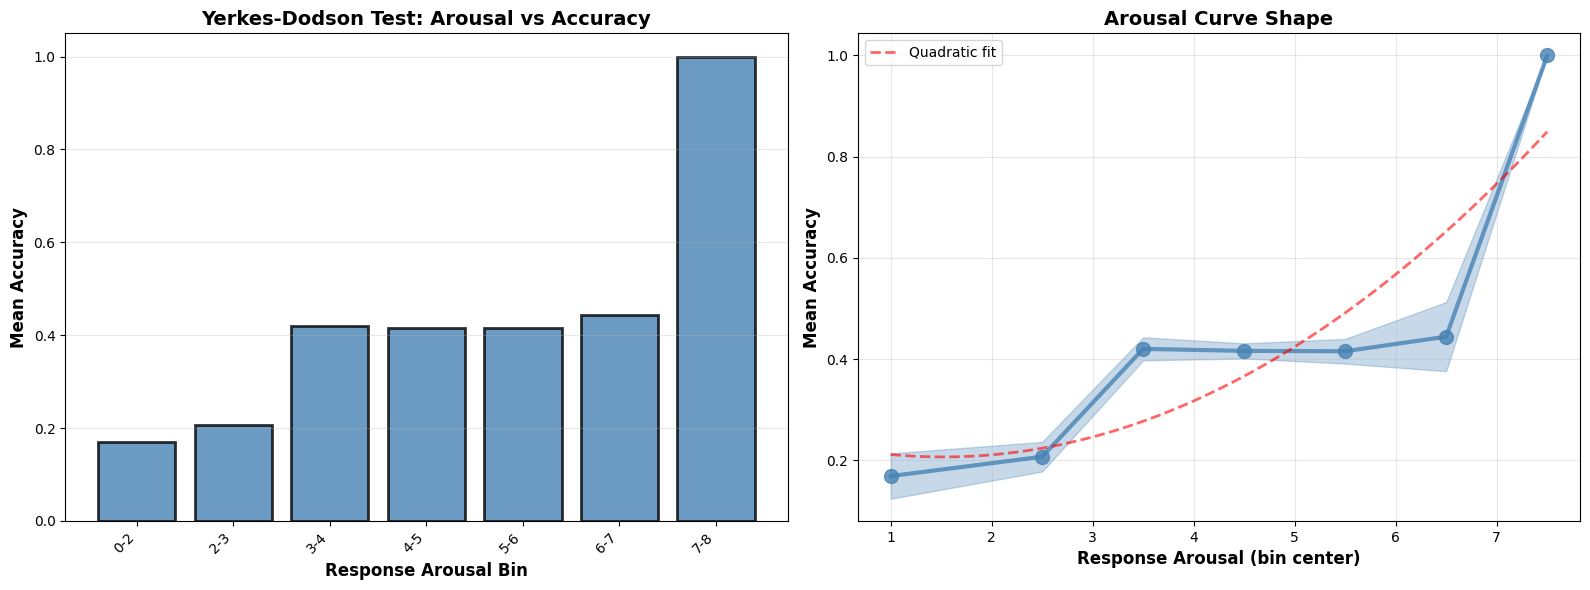


Yerkes-Dodson Analysis:
arousal_bin  mean_accuracy  count
     (0, 2]       0.169014     71
     (2, 3]       0.207254    193
     (3, 4]       0.420382    471
     (4, 5]       0.416364   1100
     (5, 6]       0.415648    409
     (6, 7]       0.444444     54
     (7, 8]       1.000000      2

✗ No clear inverted-U pattern


In [ ]:
# Test for inverted-U relationship between arousal and accuracy

# Bin responses by arousal
bins = [0, 2, 3, 4, 5, 6, 7, 8, 10]
df['arousal_bin'] = pd.cut(df['arousal_response'], bins=bins)

# Calculate mean accuracy per bin
arousal_accuracy = df.groupby('arousal_bin', observed=True).agg({
    'answer_correctness': ['mean', 'sem', 'count']
}).reset_index()

arousal_accuracy.columns = ['arousal_bin', 'mean_accuracy', 'sem', 'count']
arousal_accuracy['bin_center'] = arousal_accuracy['arousal_bin'].apply(lambda x: x.mid)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Bar plot with error bars
ax = axes[0]
bars = ax.bar(range(len(arousal_accuracy)), arousal_accuracy['mean_accuracy'],
            #   yerr=arousal_accuracy['sem'], capsize=5,
              color='steelblue', alpha=0.8, edgecolor='black', linewidth=2)

# Add count labels
# for i, (bar, count) in enumerate(zip(bars, arousal_accuracy['count'])):
#     ax.text(i, 
#             bar.get_height() + arousal_accuracy['sem'].iloc[i],
#             f'n={count}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Arousal', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Yerkes-Dodson Test: Arousal vs Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(arousal_accuracy)))
ax.set_xticklabels([f'{int(x.left)}-{int(x.right)}' for x in arousal_accuracy['arousal_bin']], 
                    rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add optimal range if visible
# if len(arousal_accuracy) > 3:
#     optimal_idx = arousal_accuracy['mean_accuracy'].idxmax()
#     ax.axvline(x=optimal_idx, color='red', linestyle='--', linewidth=2, 
#                alpha=0.5, label=f'Optimal: {arousal_accuracy.iloc[optimal_idx]["arousal_bin"]}')
#     ax.legend()

# RIGHT: Line plot to see curve shape
ax = axes[1]
ax.plot(arousal_accuracy['bin_center'], arousal_accuracy['mean_accuracy'],
        'o-', linewidth=3, markersize=10, color='steelblue', alpha=0.8)
ax.fill_between(arousal_accuracy['bin_center'],
                arousal_accuracy['mean_accuracy'] - arousal_accuracy['sem'],
                arousal_accuracy['mean_accuracy'] + arousal_accuracy['sem'],
                alpha=0.3, color='steelblue')

ax.set_xlabel('Response Arousal (bin center)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Arousal Curve Shape', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Test for quadratic fit
from numpy.polynomial import polynomial as P
x = arousal_accuracy['bin_center'].values
y = arousal_accuracy['mean_accuracy'].values
if len(x) > 3:
    # Fit quadratic
    z = np.polyfit(x, y, 2)
    p = np.poly1d(z)
    x_smooth = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_smooth, p(x_smooth), 'r--', linewidth=2, alpha=0.6, label='Quadratic fit')
    ax.legend()
    
    # Check if inverted-U (negative quadratic coefficient)
    # if z[0] < 0:
    #     optimal_arousal = -z[1] / (2 * z[0])
    #     ax.axvline(x=optimal_arousal, color='red', linestyle=':', linewidth=2, alpha=0.5)
    #     ax.text(optimal_arousal, ax.get_ylim()[1] * 0.95, 
    #             f'Optimal≈{optimal_arousal:.1f}', ha='center', fontweight='bold',
    #             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
# plt.savefig('../visualizations/yerkes_dodson_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nYerkes-Dodson Analysis:")
print(arousal_accuracy[['arousal_bin', 'mean_accuracy', 'count']].to_string(index=False))
if len(x) > 3 and z[0] < 0:
    print(f"\n✓ Inverted-U pattern detected!")
    # print(f"Optimal arousal ≈ {optimal_arousal:.2f}")
else:
    print(f"\n✗ No clear inverted-U pattern")

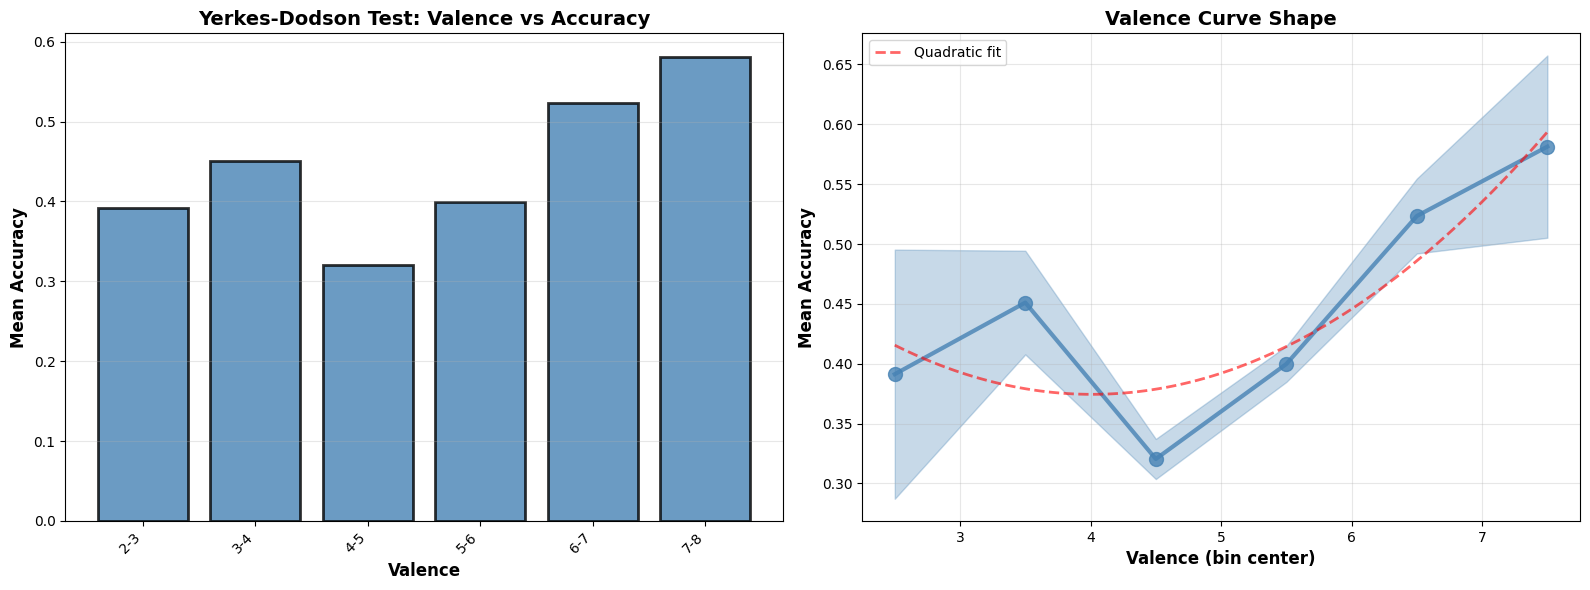


Yerkes-Dodson Analysis:
valence_bin  mean_accuracy  count
     (2, 3]       0.391304     23
     (3, 4]       0.451128    133
     (4, 5]       0.320463    777
     (5, 6]       0.399813   1068
     (6, 7]       0.523438    256
     (7, 8]       0.581395     43

✗ No clear inverted-U pattern


In [36]:
# Test for inverted-U relationship between arousal and accuracy

# Bin responses by arousal
bins = [0, 2, 3, 4, 5, 6, 7, 8, 10]
df['valence_bin'] = pd.cut(df['valence_response'], bins=bins)

# Calculate mean accuracy per bin
arousal_accuracy = df.groupby('valence_bin', observed=True).agg({
    'answer_correctness': ['mean', 'sem', 'count']
}).reset_index()

arousal_accuracy.columns = ['valence_bin', 'mean_accuracy', 'sem', 'count']
arousal_accuracy['bin_center'] = arousal_accuracy['valence_bin'].apply(lambda x: x.mid)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Bar plot with error bars
ax = axes[0]
bars = ax.bar(range(len(arousal_accuracy)), arousal_accuracy['mean_accuracy'],
            #   yerr=arousal_accuracy['sem'], capsize=5,
              color='steelblue', alpha=0.8, edgecolor='black', linewidth=2)

# Add count labels
# for i, (bar, count) in enumerate(zip(bars, arousal_accuracy['count'])):
#     ax.text(i, bar.get_height() + arousal_accuracy['sem'].iloc[i],
#             f'n={count}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Yerkes-Dodson Test: Valence vs Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(arousal_accuracy)))
ax.set_xticklabels([f'{int(x.left)}-{int(x.right)}' for x in arousal_accuracy['valence_bin']], 
                    rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add optimal range if visible
# if len(arousal_accuracy) > 3:
#     optimal_idx = arousal_accuracy['mean_accuracy'].idxmax()
#     ax.axvline(x=optimal_idx, color='red', linestyle='--', linewidth=2, 
#                alpha=0.5, label=f'Optimal: {arousal_accuracy.iloc[optimal_idx]["arousal_bin"]}')
#     ax.legend()

# RIGHT: Line plot to see curve shape
ax = axes[1]
ax.plot(arousal_accuracy['bin_center'], arousal_accuracy['mean_accuracy'],
        'o-', linewidth=3, markersize=10, color='steelblue', alpha=0.8)
ax.fill_between(arousal_accuracy['bin_center'],
                arousal_accuracy['mean_accuracy'] - arousal_accuracy['sem'],
                arousal_accuracy['mean_accuracy'] + arousal_accuracy['sem'],
                alpha=0.3, color='steelblue')

ax.set_xlabel('Valence (bin center)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Valence Curve Shape', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Test for quadratic fit
from numpy.polynomial import polynomial as P
x = arousal_accuracy['bin_center'].values
y = arousal_accuracy['mean_accuracy'].values
if len(x) > 3:
    # Fit quadratic
    z = np.polyfit(x, y, 2)
    p = np.poly1d(z)
    x_smooth = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_smooth, p(x_smooth), 'r--', linewidth=2, alpha=0.6, label='Quadratic fit')
    ax.legend()
    
    # Check if inverted-U (negative quadratic coefficient)
    # if z[0] < 0:
    #     optimal_arousal = -z[1] / (2 * z[0])
    #     ax.axvline(x=optimal_arousal, color='red', linestyle=':', linewidth=2, alpha=0.5)
    #     ax.text(optimal_arousal, ax.get_ylim()[1] * 0.95, 
    #             f'Optimal≈{optimal_arousal:.1f}', ha='center', fontweight='bold',
    #             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
# plt.savefig('../visualizations/yerkes_dodson_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nYerkes-Dodson Analysis:")
print(arousal_accuracy[['valence_bin', 'mean_accuracy', 'count']].to_string(index=False))
if len(x) > 3 and z[0] < 0:
    print(f"\n✓ Inverted-U pattern detected!")
    # print(f"Optimal arousal ≈ {optimal_arousal:.2f}")
else:
    print(f"\n✗ No clear inverted-U pattern")

MMLU RESPONSE V/A ANALYSIS

MMML responses: 1300
Overall accuracy: 35.4%

Subjects: 13
Top subjects by count:
subject
abstract_algebra                100
anatomy                         100
business_ethics                 100
college_physics                 100
econometrics                    100
formal_logic                    100
high_school_biology             100
high_school_european_history    100
international_law               100
machine_learning                100
Name: count, dtype: int64

MMLU-SPECIFIC CORRELATIONS

Response Valence → Accuracy:  r=0.064, p=0.020763
Response Arousal → Accuracy:  r=0.166, p=0.000000
Emotional Leakage → Accuracy: r=-0.294, p=0.000000

Comparison:
  MMLU Response Val → Acc:     r=0.064
  Non-MMLU Response Val → Acc: r=0.097
  Difference: 0.032


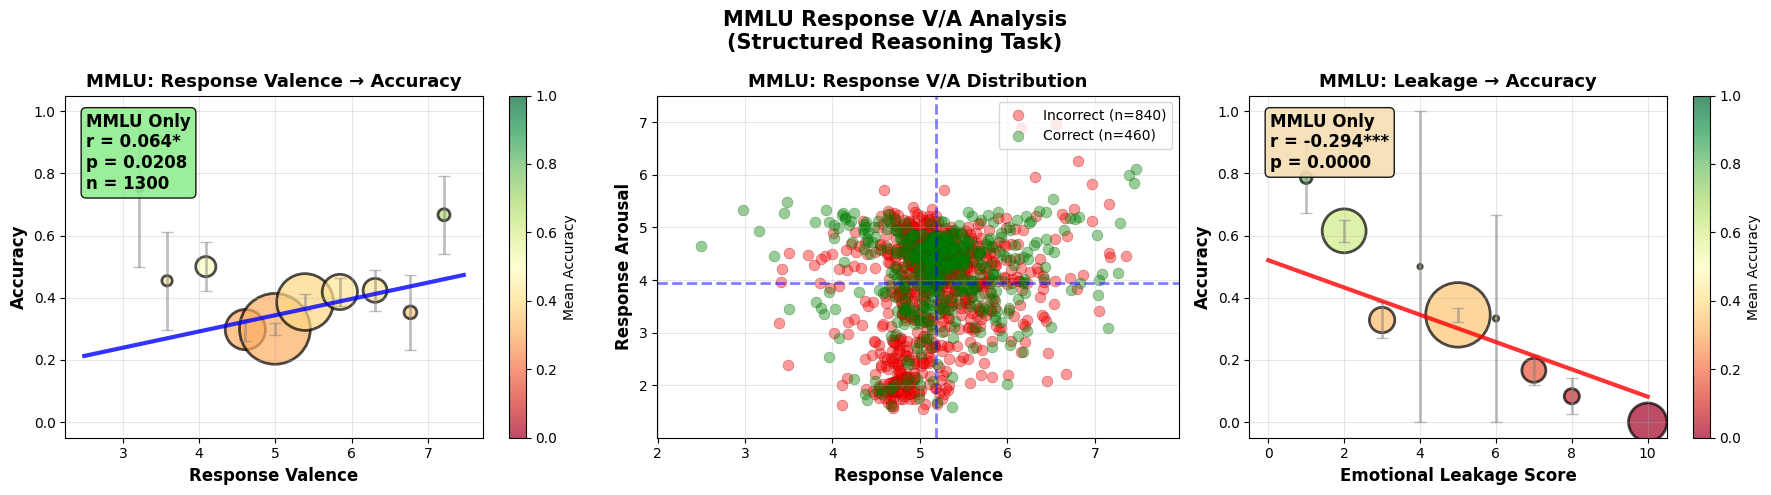


MMLU BY SUBJECT


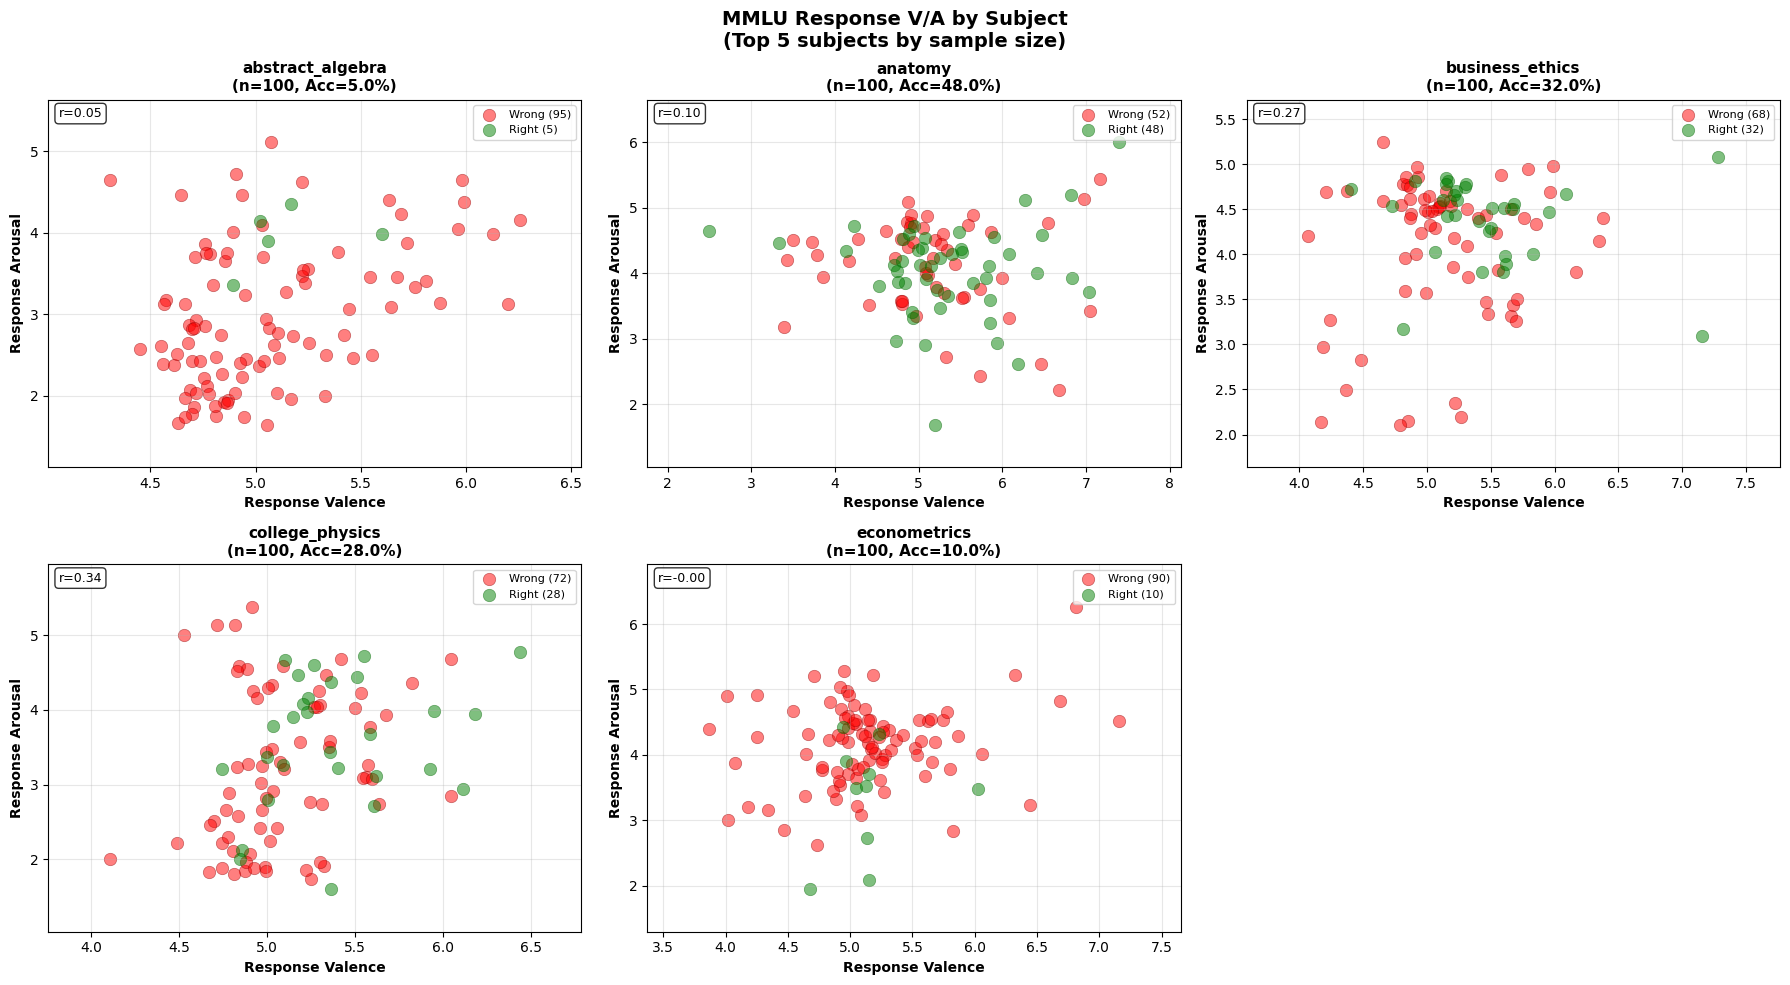


Subject-level correlations (Response Valence → Accuracy):
  abstract_algebra                         n=100  r= 0.047     p=0.6416
  anatomy                                  n=100  r= 0.102     p=0.3149
  business_ethics                          n=100  r= 0.273**   p=0.0060
  college_physics                          n=100  r= 0.341***  p=0.0005
  econometrics                             n=100  r=-0.001     p=0.9935
  formal_logic                             n=100  r=-0.101     p=0.3184
  high_school_biology                      n=100  r= 0.244*    p=0.0144
  high_school_european_history             n=100  r=-0.343***  p=0.0005
  international_law                        n=100  r= 0.031     p=0.7560
  machine_learning                         n=100  r=-0.121     p=0.2296
  philosophy                               n=100  r= 0.099     p=0.3254
  professional_psychology                  n=100  r=-0.222*    p=0.0262
  world_religions                          n=100  r=-0.094     p=0.3544

✓ MM

In [ ]:
# NEW CELL: MMLU-Specific Response V/A Analysis
# Add this as a new cell after your main analyses

# ============================================================================
# MMLU-SPECIFIC ANALYSIS
# ============================================================================

print("="*80)
print("MMLU RESPONSE V/A ANALYSIS")
print("="*80)

# Filter to MMLU only
mmlu_df = df[df['source'] == 'mmlu'].copy()
print(f"\nMMML responses: {len(mmlu_df)}")
print(f"Overall accuracy: {mmlu_df['answer_correctness'].mean():.1%}")

# Check if we have subjects
if 'subject' in mmlu_df.columns:
    print(f"\nSubjects: {mmlu_df['subject'].nunique()}")
    print("Top subjects by count:")
    print(mmlu_df['subject'].value_counts().head(10))

# Calculate correlations for MMLU
print("\n" + "="*80)
print("MMLU-SPECIFIC CORRELATIONS")
print("="*80)

corr_val, p_val = stats.pearsonr(mmlu_df['valence_response'], mmlu_df['answer_correctness'])
corr_aro, p_aro = stats.pearsonr(mmlu_df['arousal_response'], mmlu_df['answer_correctness'])
corr_leak, p_leak = stats.pearsonr(mmlu_df['emotional_leakage'], mmlu_df['answer_correctness'])

print(f"\nResponse Valence → Accuracy:  r={corr_val:.3f}, p={p_val:.6f}")
print(f"Response Arousal → Accuracy:  r={corr_aro:.3f}, p={p_aro:.6f}")
print(f"Emotional Leakage → Accuracy: r={corr_leak:.3f}, p={p_leak:.6f}")

# Compare to non-MMLU
non_mmlu_df = df[df['source'] != 'mmlu']
corr_val_other, p_val_other = stats.pearsonr(non_mmlu_df['valence_response'], non_mmlu_df['answer_correctness'])

print(f"\nComparison:")
print(f"  MMLU Response Val → Acc:     r={corr_val:.3f}")
print(f"  Non-MMLU Response Val → Acc: r={corr_val_other:.3f}")
print(f"  Difference: {abs(corr_val - corr_val_other):.3f}")

# ============================================================================
# VISUALIZATION: MMLU Response V/A vs Accuracy
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LEFT: Response Valence → Accuracy (MMLU only)
ax = axes[0]

# Bin the data
bins = np.linspace(mmlu_df['valence_response'].min(), mmlu_df['valence_response'].max(), 12)
mmlu_df['val_bin'] = pd.cut(mmlu_df['valence_response'], bins=bins)

binned = mmlu_df.groupby('val_bin', observed=True).agg({
    'answer_correctness': ['mean', 'sem', 'count'],
    'valence_response': 'mean'
}).reset_index()

binned.columns = ['bin', 'accuracy_mean', 'accuracy_sem', 'count', 'valence_mean']
binned = binned.dropna()

# Scatter
scatter = ax.scatter(binned['valence_mean'], binned['accuracy_mean'],
                     s=binned['count']*5, alpha=0.7, c=binned['accuracy_mean'],
                     cmap='RdYlGn', edgecolors='black', linewidth=2, vmin=0, vmax=1)

ax.errorbar(binned['valence_mean'], binned['accuracy_mean'],
            yerr=binned['accuracy_sem'], fmt='none', ecolor='gray',
            alpha=0.5, capsize=4, linewidth=2)

# Regression
z = np.polyfit(mmlu_df['valence_response'], mmlu_df['answer_correctness'], 1)
p = np.poly1d(z)
x_line = np.linspace(mmlu_df['valence_response'].min(), mmlu_df['valence_response'].max(), 100)
ax.plot(x_line, p(x_line), 'b-', linewidth=3, alpha=0.8)

significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
ax.text(0.05, 0.95, f'MMLU Only\nr = {corr_val:.3f}{significance}\np = {p_val:.4f}\nn = {len(mmlu_df)}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen' if p_val < 0.05 else 'wheat', alpha=0.9),
        fontweight='bold')

ax.set_xlabel('Response Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('MMLU: Response Valence → Accuracy', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Mean Accuracy', fontsize=10)

# MIDDLE: V/A Space (MMLU)
ax = axes[1]

correct = mmlu_df[mmlu_df['answer_correctness'] == 1]
incorrect = mmlu_df[mmlu_df['answer_correctness'] == 0]

ax.scatter(incorrect['valence_response'], incorrect['arousal_response'],
           c='red', s=60, alpha=0.4, edgecolors='darkred', linewidth=0.5,
           label=f'Incorrect (n={len(incorrect)})')

ax.scatter(correct['valence_response'], correct['arousal_response'],
           c='green', s=60, alpha=0.4, edgecolors='darkgreen', linewidth=0.5,
           label=f'Correct (n={len(correct)})')

# Add mean lines
mean_val = mmlu_df['valence_response'].mean()
mean_aro = mmlu_df['arousal_response'].mean()
ax.axhline(y=mean_aro, color='blue', linestyle='--', alpha=0.5, linewidth=2)
ax.axvline(x=mean_val, color='blue', linestyle='--', alpha=0.5, linewidth=2)

# Auto-zoom
val_min, val_max = mmlu_df['valence_response'].min(), mmlu_df['valence_response'].max()
aro_min, aro_max = mmlu_df['arousal_response'].min(), mmlu_df['arousal_response'].max()
val_padding = (val_max - val_min) * 0.1 or 0.5
aro_padding = (aro_max - aro_min) * 0.1 or 0.5

ax.set_xlim(val_min - val_padding, val_max + val_padding)
ax.set_ylim(aro_min - aro_padding, aro_max + aro_padding)

ax.set_xlabel('Response Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Arousal', fontsize=12, fontweight='bold')
ax.set_title('MMLU: Response V/A Distribution', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

# RIGHT: Leakage → Accuracy (MMLU)
ax = axes[2]

bins_leak = np.linspace(mmlu_df['emotional_leakage'].min(), mmlu_df['emotional_leakage'].max(), 10)
mmlu_df['leak_bin'] = pd.cut(mmlu_df['emotional_leakage'], bins=bins_leak)

binned_leak = mmlu_df.groupby('leak_bin', observed=True).agg({
    'answer_correctness': ['mean', 'sem', 'count'],
    'emotional_leakage': 'mean'
}).reset_index()

binned_leak.columns = ['bin', 'accuracy_mean', 'accuracy_sem', 'count', 'leakage_mean']
binned_leak = binned_leak.dropna()

scatter = ax.scatter(binned_leak['leakage_mean'], binned_leak['accuracy_mean'],
                     s=binned_leak['count']*5, alpha=0.7, c=binned_leak['accuracy_mean'],
                     cmap='RdYlGn', edgecolors='black', linewidth=2, vmin=0, vmax=1)

ax.errorbar(binned_leak['leakage_mean'], binned_leak['accuracy_mean'],
            yerr=binned_leak['accuracy_sem'], fmt='none', ecolor='gray',
            alpha=0.5, capsize=4, linewidth=2)

z = np.polyfit(mmlu_df['emotional_leakage'], mmlu_df['answer_correctness'], 1)
p = np.poly1d(z)
x_line = np.linspace(mmlu_df['emotional_leakage'].min(), mmlu_df['emotional_leakage'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=3, alpha=0.8)

corr_l, p_l = stats.pearsonr(mmlu_df['emotional_leakage'], mmlu_df['answer_correctness'])
significance = '***' if p_l < 0.001 else '**' if p_l < 0.01 else '*' if p_l < 0.05 else ''

ax.text(0.05, 0.95, f'MMLU Only\nr = {corr_l:.3f}{significance}\np = {p_l:.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcoral' if p_l < 0 else 'wheat', alpha=0.9),
        fontweight='bold')

ax.set_xlabel('Emotional Leakage Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('MMLU: Leakage → Accuracy', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Mean Accuracy', fontsize=10)

plt.suptitle('MMLU Response V/A Analysis\n(Structured Reasoning Task)', fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/mmlu_response_va_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# BY SUBJECT ANALYSIS (if subjects available)
# ============================================================================

if 'subject' in mmlu_df.columns and mmlu_df['subject'].nunique() > 3:
    print("\n" + "="*80)
    print("MMLU BY SUBJECT")
    print("="*80)
    
    # Get top subjects by count
    top_subjects = mmlu_df['subject'].value_counts().head(5).index
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, subject in enumerate(top_subjects):
        if idx >= 5:
            break
            
        ax = axes[idx]
        subj_data = mmlu_df[mmlu_df['subject'] == subject]
        
        # Scatter by correctness
        correct_subj = subj_data[subj_data['answer_correctness'] == 1]
        incorrect_subj = subj_data[subj_data['answer_correctness'] == 0]
        
        ax.scatter(incorrect_subj['valence_response'], incorrect_subj['arousal_response'],
                   c='red', s=80, alpha=0.5, edgecolors='darkred', linewidth=0.5,
                   label=f'Wrong ({len(incorrect_subj)})')
        
        ax.scatter(correct_subj['valence_response'], correct_subj['arousal_response'],
                   c='green', s=80, alpha=0.5, edgecolors='darkgreen', linewidth=0.5,
                   label=f'Right ({len(correct_subj)})')
        
        # Auto-zoom
        if len(subj_data) > 5:
            val_min, val_max = subj_data['valence_response'].min(), subj_data['valence_response'].max()
            aro_min, aro_max = subj_data['arousal_response'].min(), subj_data['arousal_response'].max()
            val_padding = (val_max - val_min) * 0.15 or 0.5
            aro_padding = (aro_max - aro_min) * 0.15 or 0.5
            
            ax.set_xlim(val_min - val_padding, val_max + val_padding)
            ax.set_ylim(aro_min - aro_padding, aro_max + aro_padding)
        
        ax.set_xlabel('Response Valence', fontsize=10, fontweight='bold')
        ax.set_ylabel('Response Arousal', fontsize=10, fontweight='bold')
        ax.set_title(f'{subject}\n(n={len(subj_data)}, Acc={subj_data["answer_correctness"].mean():.1%})',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
        
        # Correlation
        if len(subj_data) > 10:
            corr_subj, p_subj = stats.pearsonr(subj_data['valence_response'], subj_data['answer_correctness'])
            ax.text(0.02, 0.98, f'r={corr_subj:.2f}',
                    transform=ax.transAxes, fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Remove extra subplot
    if len(top_subjects) < 6:
        fig.delaxes(axes[5])
    
    plt.suptitle('MMLU Response V/A by Subject\n(Top 5 subjects by sample size)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    # plt.savefig('../visualizations/mmlu_by_subject_response_va.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print subject correlations
    print("\nSubject-level correlations (Response Valence → Accuracy):")
    for subject in mmlu_df['subject'].value_counts().index:
        subj_data = mmlu_df[mmlu_df['subject'] == subject]
        if len(subj_data) >= 10:
            corr_s, p_s = stats.pearsonr(subj_data['valence_response'], subj_data['answer_correctness'])
            sig = '***' if p_s < 0.001 else '**' if p_s < 0.01 else '*' if p_s < 0.05 else ''
            print(f"  {subject:40} n={len(subj_data):3}  r={corr_s:6.3f}{sig:3}  p={p_s:.4f}")

print("\n" + "="*80)
print("✓ MMLU ANALYSIS COMPLETE")
print("="*80)

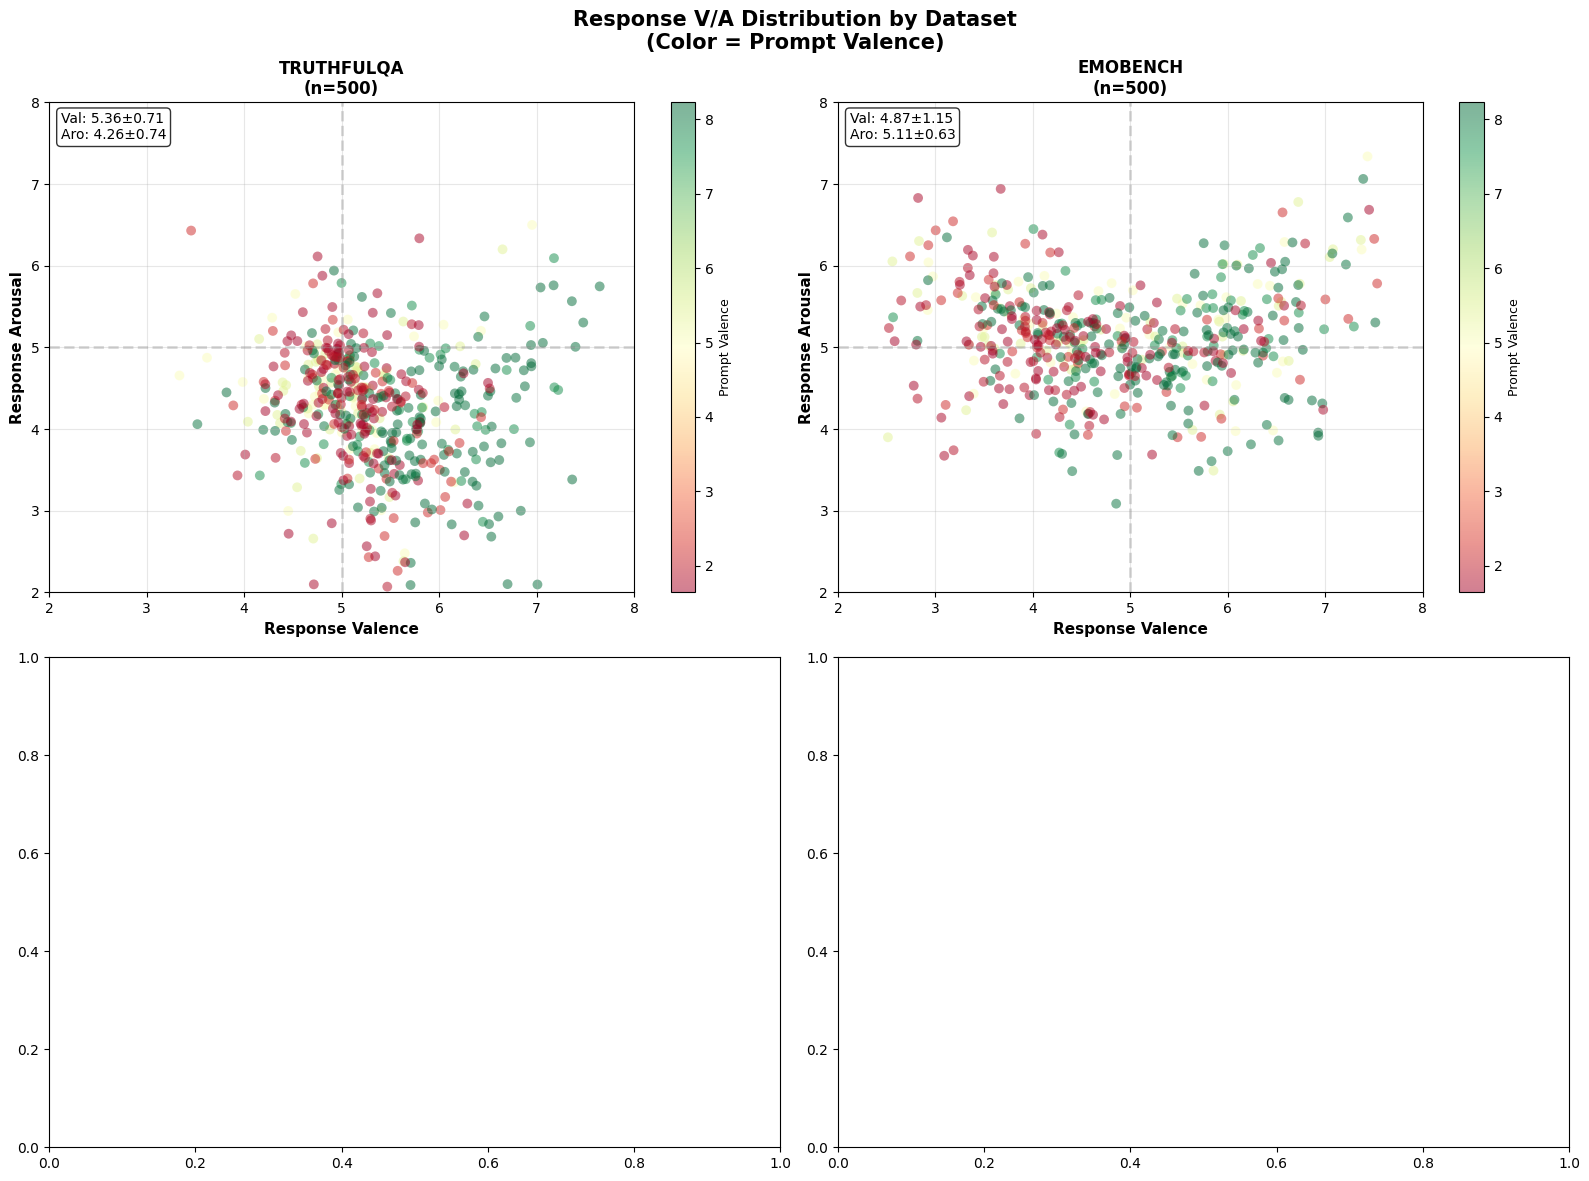


Response V/A Statistics by Dataset:

TRUTHFULQA:
  Response Valence: 5.36 ± 0.71
  Response Arousal: 4.26 ± 0.74
  Accuracy: 46.8%

EMOBENCH:
  Response Valence: 4.87 ± 1.15
  Response Arousal: 5.11 ± 0.63
  Accuracy: 42.0%


In [ ]:
# Which datasets show most emotional responses?

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

datasets = df['source'].unique()

# For each dataset, show response V/A distribution
for idx, dataset in enumerate(datasets):
    if idx >= 4:  # Max 4 subplots
        break
        
    ax = axes[idx // 2, idx % 2]
    dataset_data = df[df['source'] == dataset]
    
    # Scatter plot colored by prompt emotion
    scatter = ax.scatter(dataset_data['valence_response'], 
                        dataset_data['arousal_response'],
                        c=dataset_data['valence'], cmap='RdYlGn',
                        s=50, alpha=0.5, edgecolors='none')
    
    # Add quadrant lines
    ax.axhline(y=5, color='gray', linestyle='--', alpha=0.3, linewidth=2)
    ax.axvline(x=5, color='gray', linestyle='--', alpha=0.3, linewidth=2)
    
    ax.set_xlabel('Response Valence', fontsize=11, fontweight='bold')
    ax.set_ylabel('Response Arousal', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset.upper()}\n(n={len(dataset_data)})', fontsize=12, fontweight='bold')
    ax.set_xlim(2, 8)
    ax.set_ylim(2, 8)
    ax.grid(alpha=0.3)
    
    # Add stats
    mean_val = dataset_data['valence_response'].mean()
    mean_aro = dataset_data['arousal_response'].mean()
    std_val = dataset_data['valence_response'].std()
    std_aro = dataset_data['arousal_response'].std()
    
    ax.text(0.02, 0.98, 
            f'Val: {mean_val:.2f}±{std_val:.2f}\nAro: {mean_aro:.2f}±{std_aro:.2f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Prompt Valence', fontsize=9)

plt.suptitle('Response V/A Distribution by Dataset\n(Color = Prompt Valence)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/response_va_by_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nResponse V/A Statistics by Dataset:")
for dataset in datasets:
    dataset_data = df[df['source'] == dataset]
    print(f"\n{dataset.upper()}:")
    print(f"  Response Valence: {dataset_data['valence_response'].mean():.2f} ± {dataset_data['valence_response'].std():.2f}")
    print(f"  Response Arousal: {dataset_data['arousal_response'].mean():.2f} ± {dataset_data['arousal_response'].std():.2f}")
    print(f"  Accuracy: {dataset_data['answer_correctness'].mean():.1%}")

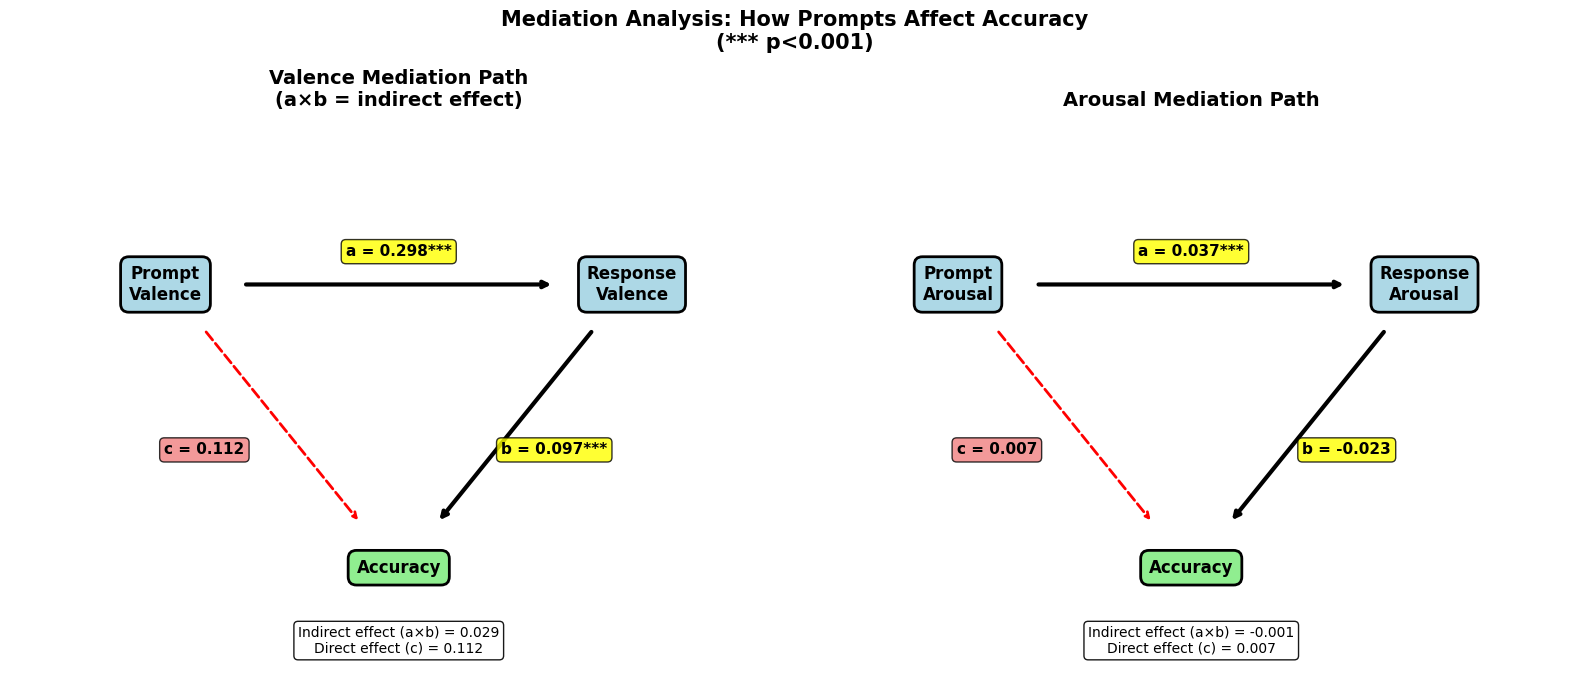


Mediation Analysis Results:

VALENCE:
  Path a (Prompt → Response): r=0.298, p=0.000000
  Path b (Response → Accuracy): r=0.097, p=0.002250
  Path c (Prompt → Accuracy total): r=0.112, p=0.000398
  Indirect effect (a×b): 0.029
  Mediation: 25.7% of total effect

AROUSAL:
  Path a (Prompt → Response): r=0.037, p=0.248464
  Path b (Response → Accuracy): r=-0.023, p=0.462148
  Path c (Prompt → Accuracy total): r=0.007, p=0.829175
  Indirect effect (a×b): -0.001


In [ ]:
# Show the causal chain: Prompt Emotion → Response Emotion → Accuracy

from scipy import stats

# Calculate path coefficients
# Path A: Prompt → Response
a_val, p_a_val = stats.pearsonr(df['valence'], df['valence_response'])
a_aro, p_a_aro = stats.pearsonr(df['arousal'], df['arousal_response'])

# Path B: Response → Accuracy (controlling for prompt)
# Use partial correlation or just direct correlation
b_val, p_b_val = stats.pearsonr(df['valence_response'], df['answer_correctness'])
b_aro, p_b_aro = stats.pearsonr(df['arousal_response'], df['answer_correctness'])

# Path C: Prompt → Accuracy (total effect)
c_val, p_c_val = stats.pearsonr(df['valence'], df['answer_correctness'])
c_aro, p_c_aro = stats.pearsonr(df['arousal'], df['answer_correctness'])

# Create path diagram
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Valence mediation
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Boxes
box_style = dict(boxstyle='round,pad=0.5', facecolor='lightblue', edgecolor='black', linewidth=2)
ax.text(2, 7, 'Prompt\nValence', ha='center', va='center', fontsize=12, 
        fontweight='bold', bbox=box_style)
ax.text(8, 7, 'Response\nValence', ha='center', va='center', fontsize=12,
        fontweight='bold', bbox=box_style)
ax.text(5, 2, 'Accuracy', ha='center', va='center', fontsize=12,
        fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', 
                                      edgecolor='black', linewidth=2))

# Arrows
arrow_props = dict(arrowstyle='->', lw=3, color='black')

# Path A: Prompt → Response
ax.annotate('', xy=(7, 7), xytext=(3, 7), arrowprops=arrow_props)
ax.text(5, 7.5, f'a = {a_val:.3f}***', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Path B: Response → Accuracy
ax.annotate('', xy=(5.5, 2.8), xytext=(7.5, 6.2), arrowprops=arrow_props)
ax.text(7, 4, f'b = {b_val:.3f}***', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Path C (total): Prompt → Accuracy
ax.annotate('', xy=(4.5, 2.8), xytext=(2.5, 6.2), 
           arrowprops=dict(arrowstyle='->', lw=2, color='red', linestyle='dashed'))
ax.text(2.5, 4, f'c = {c_val:.3f}', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

ax.set_title('Valence Mediation Path\n(a×b = indirect effect)', fontsize=14, fontweight='bold')

# Add mediation stats
indirect_val = a_val * b_val
ax.text(5, 0.5, f'Indirect effect (a×b) = {indirect_val:.3f}\nDirect effect (c) = {c_val:.3f}',
        ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# RIGHT: Arousal mediation
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Boxes
ax.text(2, 7, 'Prompt\nArousal', ha='center', va='center', fontsize=12,
        fontweight='bold', bbox=box_style)
ax.text(8, 7, 'Response\nArousal', ha='center', va='center', fontsize=12,
        fontweight='bold', bbox=box_style)
ax.text(5, 2, 'Accuracy', ha='center', va='center', fontsize=12,
        fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen',
                                      edgecolor='black', linewidth=2))

# Arrows
ax.annotate('', xy=(7, 7), xytext=(3, 7), arrowprops=arrow_props)
ax.text(5, 7.5, f'a = {a_aro:.3f}***', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.annotate('', xy=(5.5, 2.8), xytext=(7.5, 6.2), arrowprops=arrow_props)
ax.text(7, 4, f'b = {b_aro:.3f}', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.annotate('', xy=(4.5, 2.8), xytext=(2.5, 6.2),
           arrowprops=dict(arrowstyle='->', lw=2, color='red', linestyle='dashed'))
ax.text(2.5, 4, f'c = {c_aro:.3f}', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

ax.set_title('Arousal Mediation Path', fontsize=14, fontweight='bold')

indirect_aro = a_aro * b_aro
ax.text(5, 0.5, f'Indirect effect (a×b) = {indirect_aro:.3f}\nDirect effect (c) = {c_aro:.3f}',
        ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle('Mediation Analysis: How Prompts Affect Accuracy\n(*** p<0.001)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/mediation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMediation Analysis Results:")
print("\nVALENCE:")
print(f"  Path a (Prompt → Response): r={a_val:.3f}, p={p_a_val:.6f}")
print(f"  Path b (Response → Accuracy): r={b_val:.3f}, p={p_b_val:.6f}")
print(f"  Path c (Prompt → Accuracy total): r={c_val:.3f}, p={p_c_val:.6f}")
print(f"  Indirect effect (a×b): {indirect_val:.3f}")
print(f"  Mediation: {abs(indirect_val/c_val)*100:.1f}% of total effect")

print("\nAROUSAL:")
print(f"  Path a (Prompt → Response): r={a_aro:.3f}, p={p_a_aro:.6f}")
print(f"  Path b (Response → Accuracy): r={b_aro:.3f}, p={p_b_aro:.6f}")
print(f"  Path c (Prompt → Accuracy total): r={c_aro:.3f}, p={p_c_aro:.6f}")
print(f"  Indirect effect (a×b): {indirect_aro:.3f}")

In [ ]:
# Create comprehensive summary table

summary_stats = {
    'Emotional Contagion': [
        ('Prompt Val → Response Val', *stats.pearsonr(df['valence'], df['valence_response'])),
        ('Prompt Aro → Response Aro', *stats.pearsonr(df['arousal'], df['arousal_response']))
    ],
    'Response Effects': [
        ('Response Val → Accuracy', *stats.pearsonr(df['valence_response'], df['answer_correctness'])),
        ('Response Aro → Accuracy', *stats.pearsonr(df['arousal_response'], df['answer_correctness'])),
        ('Response Val → Task Focus', *stats.pearsonr(df['valence_response'], df['task_focus'])),
        ('Response Val → Leakage', *stats.pearsonr(df['valence_response'], df['emotional_leakage']))
    ],
    'Alignment Effects': [
        ('Val Alignment → Accuracy', *stats.pearsonr(df['valence_alignment'], df['answer_correctness'])),
        ('Aro Alignment → Accuracy', *stats.pearsonr(df['arousal_alignment'], df['answer_correctness'])),
        ('Emotional Distance → Accuracy', *stats.pearsonr(df['emotional_distance'], df['answer_correctness']))
    ]
}

# Create formatted table
print("\n" + "="*80)
print("COMPREHENSIVE CORRELATION SUMMARY")
print("="*80)

all_results = []
for category, correlations in summary_stats.items():
    print(f"\n{category}:")
    print("-"*80)
    for name, r, p in correlations:
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {name:40} r={r:7.3f}{sig:3}  p={p:.6f}")
        all_results.append({
            'Category': category,
            'Relationship': name,
            'r': r,
            'p': p,
            'Significant': sig
        })

# Save to CSV
results_df = pd.DataFrame(all_results)
# results_df.to_csv('../visualizations/response_va_correlations.csv', index=False)
# print(f"\n✓ Saved to ../visualizations/response_va_correlations.csv")


COMPREHENSIVE CORRELATION SUMMARY

Emotional Contagion:
--------------------------------------------------------------------------------
  Prompt Val → Response Val                r=  0.298***  p=0.000000
  Prompt Aro → Response Aro                r=  0.037     p=0.248464

Response Effects:
--------------------------------------------------------------------------------
  Response Val → Accuracy                  r=  0.097**   p=0.002250
  Response Aro → Accuracy                  r= -0.023     p=0.462148
  Response Val → Task Focus                r=  0.077*    p=0.014271
  Response Val → Leakage                   r= -0.000     p=0.989804

Alignment Effects:
--------------------------------------------------------------------------------
  Val Alignment → Accuracy                 r= -0.064*    p=0.044653
  Aro Alignment → Accuracy                 r= -0.013     p=0.685664
  Emotional Distance → Accuracy            r= -0.043     p=0.171652

✓ Saved to ../visualizations/response_va_correla